# **Pastikan sudah di download terlebih dahulu colabnya, atau di salin. Terimakasih :)**

# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

%matplotlib inline

In [86]:
train = pd.read_csv('messi_all_goals.csv')
train.head()

,competition,match_stage,date,venue,club,opponent,match_score,player_position,goal_minute,score_at_goal,goal_type,assist_player,season,goal_decade,is_home_goal,goal_minute_bucket
0,2ª B - Grupo III,2,2004-09-05,Home,FC Barcelona B,Girona FC,1:2,LW,65,1:2,Left-footed shot,Dani Fernández,2004-05,2000s,True,61-75
1,2ª B - Grupo III,4,2004-09-18,Home,FC Barcelona B,RCD Espanyol B,2:0,LW,88,2:0,Left-footed shot,Dani Fernández,2004-05,2000s,True,76-90
2,2ª B - Grupo III,10,2004-10-31,Away,FC Barcelona B,Villajoyosa CF,2:1,AM,2,0:1,Not reported,Not Applicable,2004-05,2000s,False,0-15
3,2ª B - Grupo III,14,2004-11-28,Away,FC Barcelona B,UE Figueres,2:2,AM,20,0:1,Not reported,Not Applicable,2004-05,2000s,False,16-30
4,2ª B - Grupo III,17,2004-12-19,Home,FC Barcelona B,CD Alcoyano,2:0,CF,40,2:0,Left-footed shot,Not Applicable,2004-05,2000s,True,31-45


### Exploratory Data Analysis

In [87]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 790 entries, 0 to 789
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   competition         790 non-null    object
 1   match_stage         790 non-null    object
 2   date                790 non-null    object
 3   venue               790 non-null    object
 4   club                790 non-null    object
 5   opponent            790 non-null    object
 6   match_score         790 non-null    object
 7   player_position     790 non-null    object
 8   goal_minute         790 non-null    int64 
 9   score_at_goal       790 non-null    object
 10  goal_type           790 non-null    object
 11  assist_player       790 non-null    object
 12  season              790 non-null    object
 13  goal_decade         790 non-null    object
 14  is_home_goal        790 non-null    bool  
 15  goal_minute_bucket  790 non-null    object
dtypes: bool(1), int64(1), obje

In [88]:
train.describe()

,goal_minute
count,790.000000
mean,51.981013
std,26.045313
min,2.000000
25%,29.000000
50%,54.000000
75%,75.000000
max,110.000000


In [89]:
train.isnull().sum()

competition           0
match_stage           0
date                  0
venue                 0
club                  0
opponent              0
match_score           0
player_position       0
goal_minute           0
score_at_goal         0
goal_type             0
assist_player         0
season                0
goal_decade           0
is_home_goal          0
goal_minute_bucket    0
dtype: int64

C:\Users\broig\AppData\Local\Temp\ipykernel_3736\138703936.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='goal_type', data=train, palette='RdBu_r')


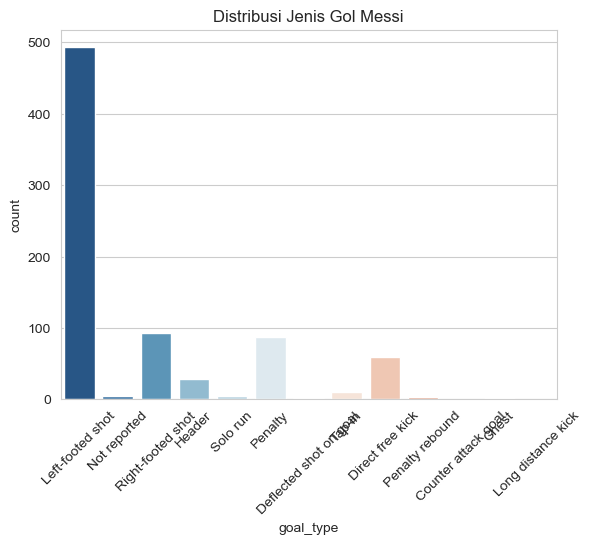

In [90]:
# Cek Distribusi Target
sns.set_style('whitegrid')
sns.countplot(x='goal_type', data=train, palette='RdBu_r')

plt.title('Distribusi Jenis Gol Messi')
plt.xticks(rotation=45)
plt.show()

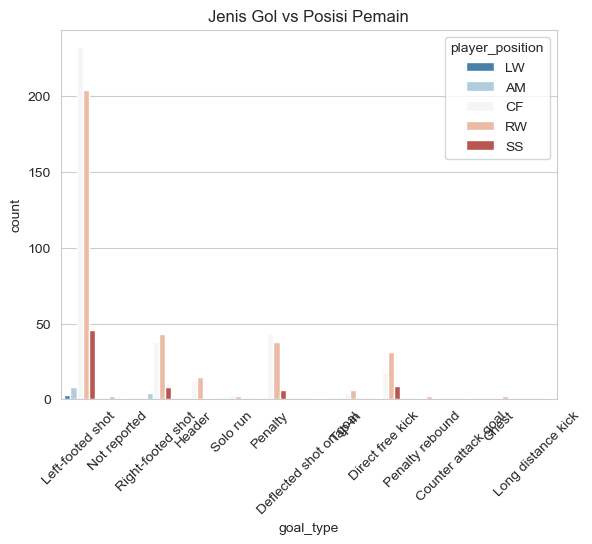

In [91]:
# Goal Type vs Posisi
sns.set_style('whitegrid')
sns.countplot(x='goal_type', hue='player_position', data=train, palette='RdBu_r')

plt.title('Jenis Gol vs Posisi Pemain')
plt.xticks(rotation=45)
plt.show()

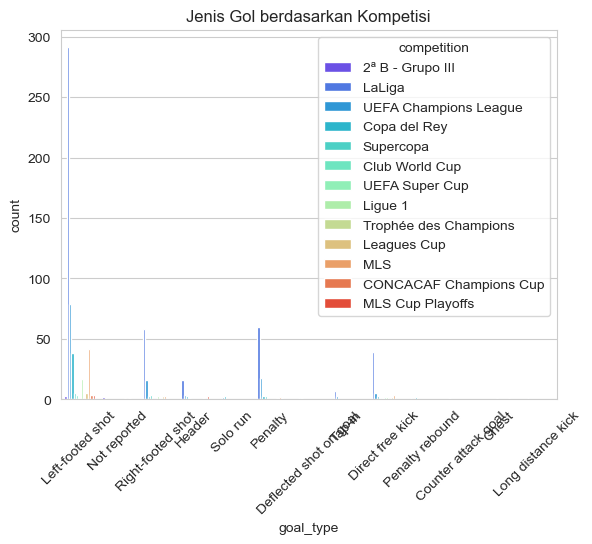

In [92]:
# Goal Type vs Kompetisi
sns.set_style('whitegrid')
sns.countplot(x='goal_type', hue='competition', data=train, palette='rainbow')

plt.title('Jenis Gol berdasarkan Kompetisi')
plt.xticks(rotation=45)
plt.show()

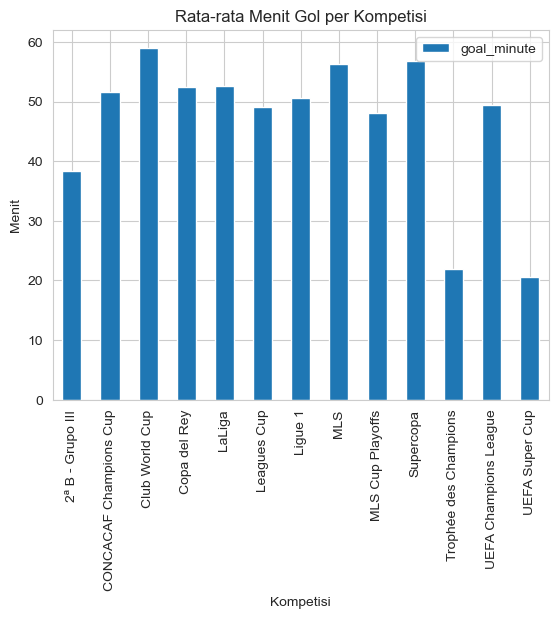

In [93]:
# Rata-rata Menit Gol per Kompetisi
goal_avg = train.groupby('competition')['goal_minute'].mean()
goal_avg = pd.DataFrame(goal_avg)

goal_avg.plot.bar(y='goal_minute')
plt.title("Rata-rata Menit Gol per Kompetisi")
plt.ylabel("Menit")
plt.xlabel("Kompetisi")
plt.show()

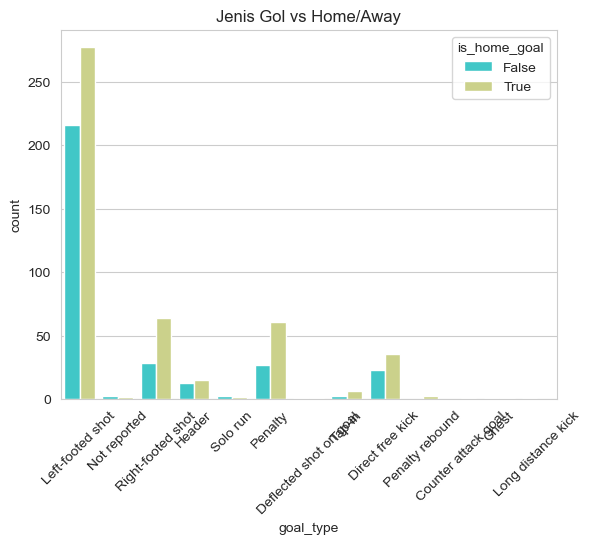

In [94]:
# Goal Type vs Home/Away
sns.set_style('whitegrid')
sns.countplot(x='goal_type', hue='is_home_goal', data=train, palette='rainbow')

plt.title('Jenis Gol vs Home/Away')
plt.xticks(rotation=45)
plt.show()

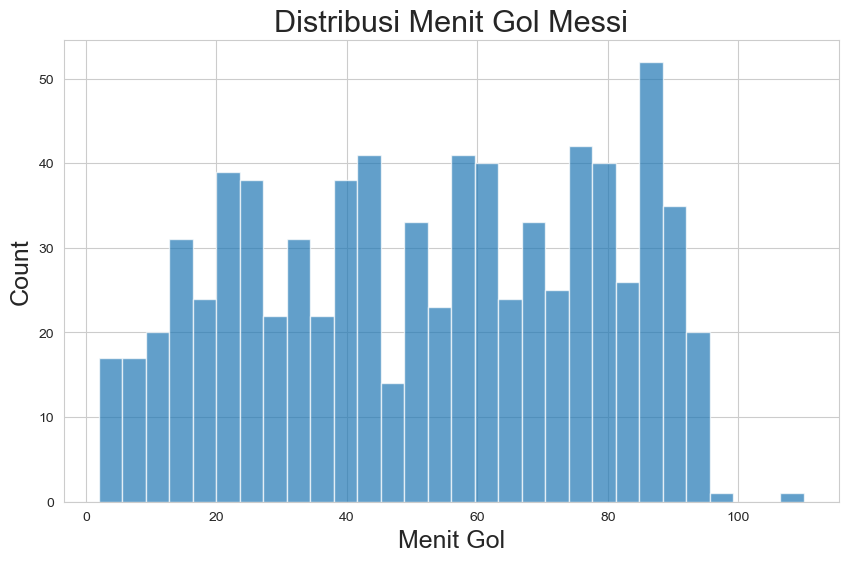

In [95]:
# Distribusi Menit Gol
plt.xlabel("Menit Gol", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Distribusi Menit Gol Messi", fontsize=22)

train['goal_minute'].hist(bins=30, alpha=0.7, figsize=(10,6))
plt.show()

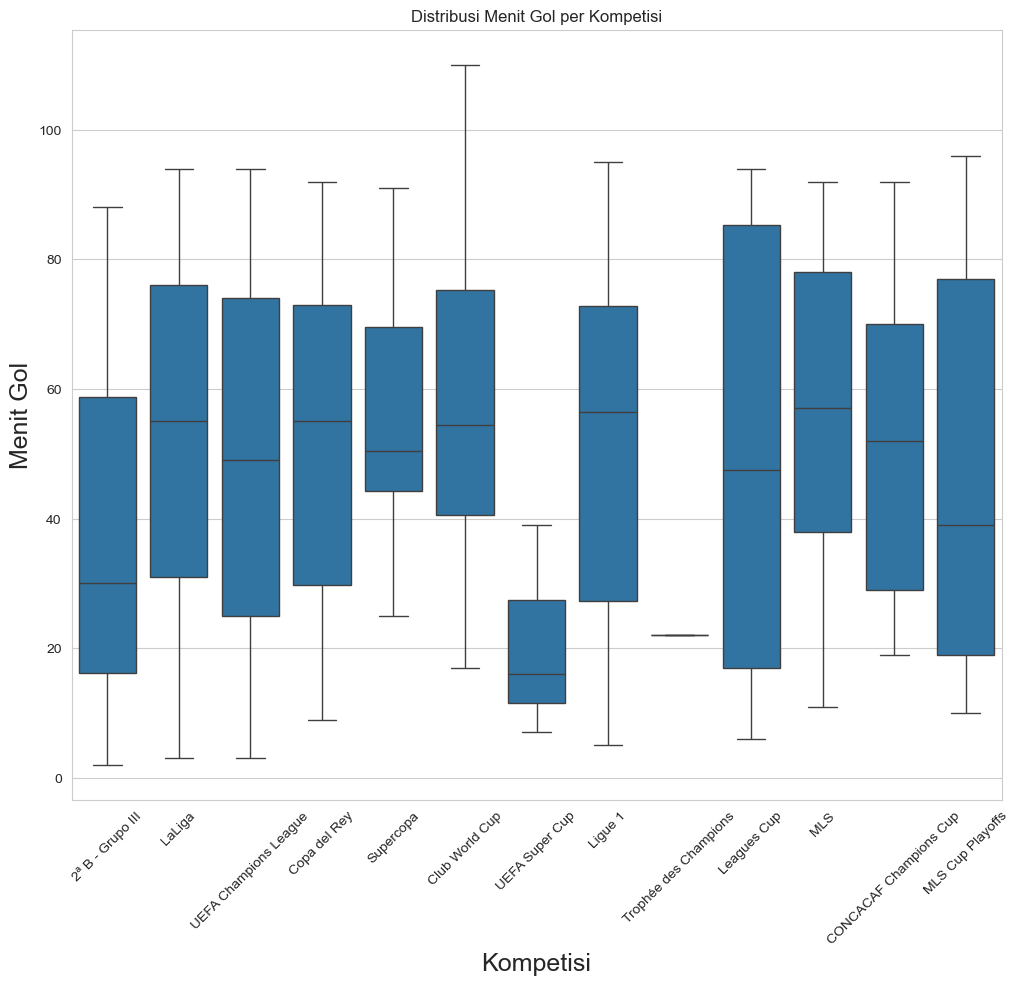

In [96]:
# Boxplot Menit Gol per Kompetisi
plt.figure(figsize=(12, 10))

sns.boxplot(x='competition', y='goal_minute', data=train)

plt.xlabel("Kompetisi", fontsize=18)
plt.ylabel("Menit Gol", fontsize=18)
plt.title("Distribusi Menit Gol per Kompetisi")
plt.xticks(rotation=45)
plt.show()

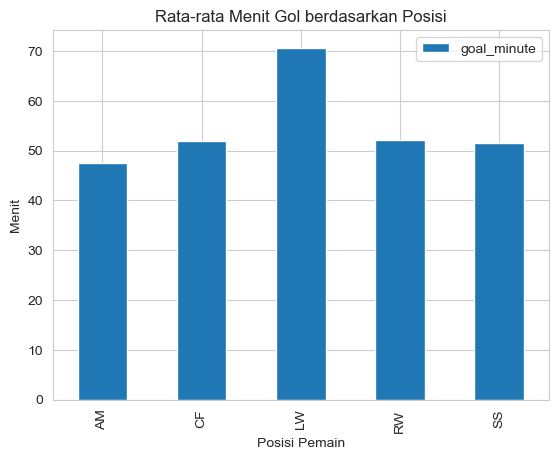

In [97]:
# Rata-rata Menit Gol per Posisi
pos_avg = train.groupby('player_position')['goal_minute'].mean()
pos_avg = pd.DataFrame(pos_avg)

pos_avg.plot.bar(y='goal_minute')
plt.title("Rata-rata Menit Gol berdasarkan Posisi")
plt.ylabel("Menit")
plt.xlabel("Posisi Pemain")
plt.show()

### Fitur Engineering

In [98]:
# ===============================
# FEATURE ENGINEERING (MESSI)
# ===============================

# 1. Tidak perlu imputasi (data sudah bersih)
print("Missing values:\n", train.isnull().sum())

# 2. Drop kolom yang tidak relevan untuk model
train.drop(['date', 'match_score', 'score_at_goal'], axis=1, inplace=True)

# 3. Encoding semua fitur kategorikal
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in train.select_dtypes(include='object').columns:
    train[col] = le.fit_transform(train[col])

# 4. Feature tambahan (opsional, tapi bagus untuk nilai)
# Gol menit akhir (lebih dari menit 75)
train['late_goal'] = train['goal_minute'].apply(lambda x: 1 if x > 75 else 0)

# 5. Cek hasil akhir
train.head()

Missing values:
 competition           0
match_stage           0
date                  0
venue                 0
club                  0
opponent              0
match_score           0
player_position       0
goal_minute           0
score_at_goal         0
goal_type             0
assist_player         0
season                0
goal_decade           0
is_home_goal          0
goal_minute_bucket    0
dtype: int64


,competition,match_stage,venue,club,opponent,player_position,goal_minute,goal_type,assist_player,season,goal_decade,is_home_goal,goal_minute_bucket,late_goal
0,0,11,1,1,58,2,65,5,19,0,0,True,4,0
1,0,32,1,1,88,2,88,5,19,0,0,True,5,1
2,0,1,0,1,123,0,2,7,57,0,0,False,0,0
3,0,5,0,1,120,0,20,7,57,0,0,False,1,0
4,0,8,1,1,19,1,40,5,57,0,0,True,2,0


### Training

In [99]:
# Feature (input)
X = train[[
    'goal_minute',
    'is_home_goal',
    'goal_minute_bucket',
    'season',
    'goal_decade',
    'player_position',
    'late_goal'   # fitur tambahan (kalau kamu pakai)
]]

# Target (output)
y = train['goal_type']

In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (553, 7)
Test shape : (237, 7)


# **KNN**

In [101]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [102]:
y_pred_knn = knn.predict(X_test)

### Evaluation

In [103]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model KNN
accuracy = accuracy_score(y_test, y_pred_knn)
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:")
print(classification_report(y_test, y_pred_knn, zero_division=0))

Akurasi Model KNN: 0.57
Confusion Matrix:
[[  0   0   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   0   0  20   0   0   0   0   0   0   0]
 [  0   0   0   0   0   8   0   0   0   0   0   0   0]
 [  0   0   0   4   0 133   0   0   4   0   1   0   0]
 [  0   0   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   0   0   3   0   0   0   0   0   0   0]
 [  0   0   0   1   1  22   0   0   0   0   3   0   0]
 [  0   0   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   0   1  27   0   0   0   0   1   0   0]
 [  0   0   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   0   0   2   0   0   0   0   0   0   0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
  

# **Naive Bayes**

In [104]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

### Evaluation

In [105]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model Naive Bayes
accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Classification Report:")
print(classification_report(y_test, y_pred_nb, zero_division=0))

Akurasi Model Naive Bayes: 0.21
Confusion Matrix:
[[ 0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 0  0  0  0  0  6  0  2  0  0  0  0 12]
 [ 0  0  0  0  0  1  0  2  0  0  0  0  5]
 [ 0  0  0  0  0 47  0 19  0  1  0  0 75]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  2  0  1  0  0  0  0  0]
 [ 0  0  0  0  0  6  0  4  0  0  0  0 17]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 0  0  0  0  0 14  0  1  0  1  0  0 13]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  1]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00        20
           4       0.00      0.00      0.00         8
           5       0.59      0.33      0.42       142
 

# **Decision Tree**

In [106]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi model (pakai balancing biar lebih bagus)
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Training model
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [107]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model Decision Tree
accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Akurasi Model Decision Tree: 0.46
Confusion Matrix:
[[ 0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  1  0  0  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  3  2 12  0  0  1  0  2  0  0]
 [ 0  0  0  0  1  6  0  0  0  0  0  0  1]
 [ 0  0  0 11  4 92  0  1 15  0 15  1  3]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  1  0  1  0  0  0  0  0]
 [ 0  0  0  1  0 16  0  0  3  0  6  0  1]
 [ 0  0  0  0  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  2  4 11  0  0  3  0  9  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  1  0  0]
 [ 0  0  0  0  0  1  0  0  0  0  1  0  0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.18      0.15      0.16        20
           4       0.08      0.12      0.10         8
           5       0.64      0.65      0.65       142

Krena yang lebih bagus adalah nilai evaluasinya model Naive Bayes, maka kita akan tes menggunakan data baru

In [108]:
# Data penumpang baru
# Format: [goal_minute = 80, is_home_goal = 1, goal_minute_bucket = 5, season = 10, goal_decade = 2, player_position = 1, late_goal = 1)]
new_data = np.array([[80, 1, 5, 10, 2, 1, 1]])

# Prediksi jenis gol
new_prediction = nb.predict(new_data)
print("Prediksi Jenis Gol:", new_prediction[0])


# Prediksi probabilitas
proba = nb.predict_proba(new_data)
print("Probabilitas Prediksi:", proba[0])

Prediksi Jenis Gol: 5
Probabilitas Prediksi: [0.         0.         0.03070534 0.00991111 0.58950468 0.
 0.21673742 0.         0.15240311 0.00073834 0.        ]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


#---------------------------------------------------------------------------------------------------------------------------------


#---------------------------------------------------------------------------------------------------------------------------------

#---------------------------------------------------------------------------------------------------------------------------------

# **Contoh Penggunaan Parameter**

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [109]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [110]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred_knn))

Akurasi Model KNN: 0.54
Confusion Matrix:
[[  0   0   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   0   0  19   0   0   0   0   1   0   0]
 [  0   0   0   0   1   7   0   0   0   0   0   0   0]
 [  0   0   0   3   2 125   0   0   6   0   5   1   0]
 [  0   0   0   0   0   1   0   0   0   0   0   0   0]
 [  0   0   0   0   0   3   0   0   0   0   0   0   0]
 [  0   0   0   0   1  18   0   0   1   0   7   0   0]
 [  0   0   0   0   0   0   0   0   0   0   1   0   0]
 [  0   0   0   0   0  25   0   0   2   0   2   0   0]
 [  0   0   0   0   0   0   0   0   0   0   1   0   0]
 [  0   0   0   0   0   2   0   0   0   0   0   0   0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
  

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### jika ingin mencoba semua parameter kita bisa menggunakan GridSearchCV

### Contoh penggunaan Model KNN dengan GridSearchCV

In [111]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.560622   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.549730   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.576904   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.500721   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.522523   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.582326   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.504406   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.605782   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.511646   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.584095   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.613038   
10  {'metric': 'manhatta

In [112]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [113]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}


In [114]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.54
Presisi:  0.08
Recall:   0.09
F1-Score: 0.08

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00        20
           4       0.25      0.12      0.17         8
           5       0.62      0.88      0.72       142
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         3
           8       0.11      0.04      0.06        27
           9       0.00      0.00      0.00         1
          10       0.12      0.07      0.09        29
          11       0.00      0.00      0.00         1
          12       0.00      0.00      0.00         2

    accuracy                           0.54       237
   macro avg       0.08      0.09      0.08       237
weighted avg       0

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\ProgramData\anaconda3\Lib

In [115]:
import numpy as np

# Data penumpang baru (dalam urutan sama seperti fitur model)
new_data_1 = np.array([[3, 0, 25.0, 0, 0, 7.25, 2]])

# Prediksi apakah penumpang ini selamat atau tidak
prediction = best_model.predict(new_data_1)

print("Prediksi (0 = Tidak Selamat, 1 = Selamat):", prediction[0])

Prediksi (0 = Tidak Selamat, 1 = Selamat): 5


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
